In [27]:
import pickle 

with open(r"C:\Users\ASUS\OneDrive\Desktop\AI &ML PROJECT\data\images.p","rb") as f:
    images = pickle.load(f)
with open(r"C:\Users\ASUS\OneDrive\Desktop\AI &ML PROJECT\data\labels.p","rb") as f:
    labels = pickle.load(f)

In [28]:
print(images.shape)
print(labels.shape)

(292, 100, 100)
(292,)


In [29]:
set(labels)

{'Shakti Subham', 'Sushree', 'rajesh'}

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

labels = le.fit_transform(labels)

In [22]:
set(labels)

{0, 1, 2}

In [23]:
le.inverse_transform([0])

array(['Shakti Subham'], dtype='<U13')

In [24]:
p = len(set(labels))
print("Total number of Persons: ",p)

Total number of Persons:  3


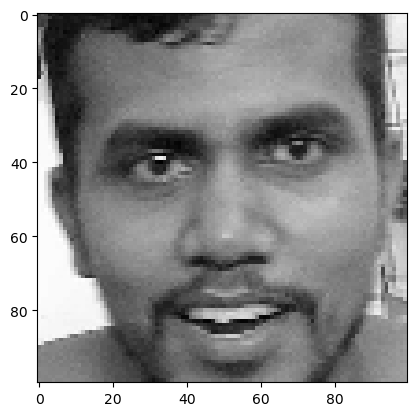

In [25]:
import matplotlib.pyplot as plt
plt.imshow(images[90],cmap='gray')
plt.show()

In [26]:
import cv2

In [37]:
def preprocessing(img):
    img = cv2.equalizeHist(img)
    img = img.reshape(100,100,1)
    img = img/255
    return img

In [38]:
import numpy as np

In [39]:
images = np.array(list(map(preprocessing,images)))
print("Shape of Input : ",images.shape)

Shape of Input :  (292, 100, 100, 1)


In [40]:
from keras.utils import to_categorical
labels = to_categorical(labels)

In [43]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from keras.layers import Conv2D, MaxPooling2D, Flatten

In [44]:
def Lenet_Model():
    model = Sequential()
    model.add(Conv2D(30,(5,5),input_shape=(100,100,1),activation = 'relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Conv2D(15,(3,3),activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Flatten())
    model.add(Dense(50,activation='relu'))
    model.add(Dense(p,activation='softmax'))
    model.compile(Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])
    return model


In [45]:
model = Lenet_Model()
model.summary()

C:\Users\ASUS\Downloads\ANACONDA\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 30)          │             780 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 30)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 46, 46, 15)          │           4,065 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 15)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7935)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │         396,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 401,798 (1.53 MB)

 Trainable params: 401,798 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
h = model.fit(images,labels,validation_split=0.1,epochs=15)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 1.0000 - loss: 4.9631e-06 - val_accuracy: 0.9667 - val_loss: 0.0765
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 1.0000 - loss: 4.5796e-06 - val_accuracy: 0.9667 - val_loss: 0.0800
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 1.0000 - loss: 3.8979e-06 - val_accuracy: 0.9667 - val_loss: 0.0820
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 1.0000 - loss: 3.7297e-06 - val_accuracy: 0.9667 - val_loss: 0.0847
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 1.0000 - loss: 3.4001e-06 - val_accuracy: 0.9667 - val_loss: 0.0870
Epoch 6/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 1.0000 - loss: 3.0505e-06 - val_accuracy: 0.9667 - val_loss: 0.0885
Epoch 7/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 1.0000 - loss: 2.8591e-06 - val_accuracy: 0.9667 - val_loss: 0.0901
Epoch 8/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 1.0000 - loss: 2.7204e-06 - 

In [48]:
model.save('final_model.h5')